# Titanic Data Analysis

## 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset

In [2]:
df_original = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
df = df_original.copy()

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Initial Data Exploration

The dataset structure and missing values were examined.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

- Age contains missing values
- Cabin has many missing values
- Embarked contains a few missing values

## 4. Data Cleaning

The `Cabin` variable was removed because it contained a large proportion of missing values.

In [5]:
df = df.drop('Cabin', axis=1)

Missing values in the `Age` variable were filled using the median because it handles extreme values better.

In [6]:
df['Age'] = df['Age'].fillna(df['Age'].median())

Missing values in the `Embarked` variable were imputed using the mode because it is a categorical variable.

In [7]:
df['Embarked'] = df["Embarked"].fillna(df["Embarked"].mode()[0])

Outliers in the `Age` variable were retained because they represent valid passenger ages.


In [8]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['Age']<lower) | (df['Age']>upper)]
outliers

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.0750,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.00,0,0,113783,26.5500,S
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.00,0,0,248706,16.0000,S
16,17,0,3,"Rice, Master. Eugene",male,2.00,4,1,382652,29.1250,Q
33,34,0,2,"Wheadon, Mr. Edward H",male,66.00,0,0,C.A. 24579,10.5000,S
...,...,...,...,...,...,...,...,...,...,...,...
827,828,1,2,"Mallet, Master. Andre",male,1.00,0,2,S.C./PARIS 2079,37.0042,C
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.00,0,0,113572,80.0000,S
831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,S
851,852,0,3,"Svensson, Mr. Johan",male,74.00,0,0,347060,7.7750,S


Missing value check after cleaning:

In [9]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 5. Feature Engineering
New variables were created to better capture survival-related patterns.

#### `Age_Group` Feature
Passengers were grouped by age ranges.

In [10]:
max_age = int(df['Age'].max())

df['Age_Group'] = pd.cut(df['Age'], bins=[0,12,18,30,50,max_age], labels=['[0-12]', '(12-18]', '(18-30]', '(30-50]', f'(50-{max_age}]'], include_lowest=True)
df.groupby('Age_Group', observed=True)['Survived'].mean()

Age_Group
[0-12]     0.579710
(12-18]    0.428571
(18-30]    0.331096
(30-50]    0.423237
(50-80]    0.343750
Name: Survived, dtype: float64

#### `FamilySize` Feature
A new feature was created to represent the total family size aboard the ship.

In [11]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

#### `IsAlone` Feature
Passengers traveling alone were identified.

In [12]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

Check the new features:

In [13]:
df[["Age", "Age_Group", "FamilySize", "IsAlone"]].head()

,Age,Age_Group,FamilySize,IsAlone
0,22.0,(18-30],2,0
1,38.0,(30-50],2,0
2,26.0,(18-30],1,1
3,35.0,(30-50],2,0
4,35.0,(30-50],1,1


In [14]:
df[["Age", "Age_Group", "FamilySize", "IsAlone"]].describe()

,Age,FamilySize,IsAlone
count,891.000000,891.000000,891.000000
mean,29.361582,1.904602,0.602694
std,13.019697,1.613459,0.489615
min,0.420000,1.000000,0.000000
25%,22.000000,1.000000,0.000000
50%,28.000000,1.000000,1.000000
75%,35.000000,2.000000,1.000000
max,80.000000,11.000000,1.000000


## 6. Exploratory Data Analysis (EDA)

### Survival Rate by Gender

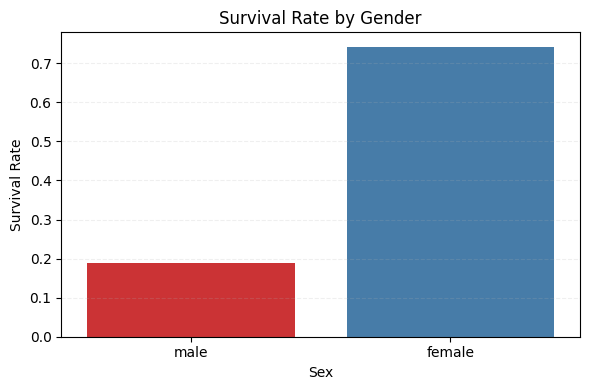

Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

In [15]:
plt.figure(figsize=(6,4))

sns.barplot(data=df, x='Sex', y='Survived', hue='Sex', palette='Set1', errorbar=None)

plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')

plt.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

(df.groupby('Sex')['Survived'].mean() * 100).round(2)

Female passengers had a significantly higher survival rate than males. Approximately 74% of female passengers survived, compared to only about 19% of male passengers, indicating that gender was strongly related to survival outcomes.

### Survival by Passenger Class

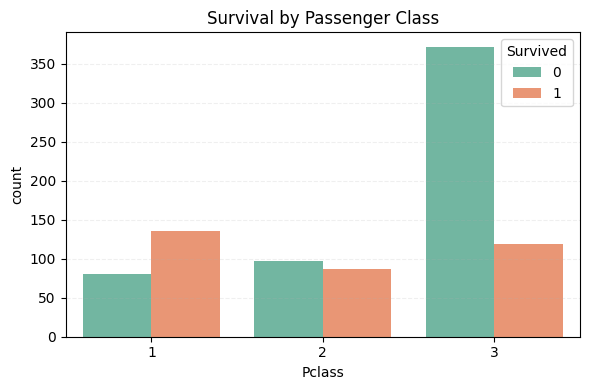

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set2')
plt.title('Survival by Passenger Class')
plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.tight_layout()

Passengers in higher classes were more likely to survive compared to those in lower classes.

### Survival by Age Group

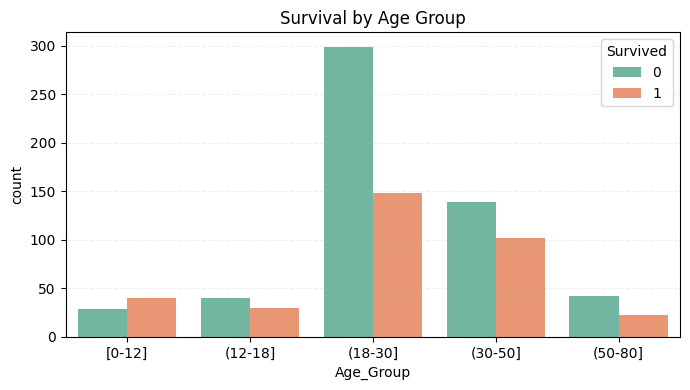

In [17]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x='Age_Group',
    hue='Survived',
    palette='Set2'
)

plt.title('Survival by Age Group')
plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.tight_layout()

Survival rates vary across different age groups. The 18–30 age group is the largest group in the dataset and also has the highest number of deaths. In all age groups, the number of passengers who did not survive is higher than the number of survivors.

### Correlation Heatmap

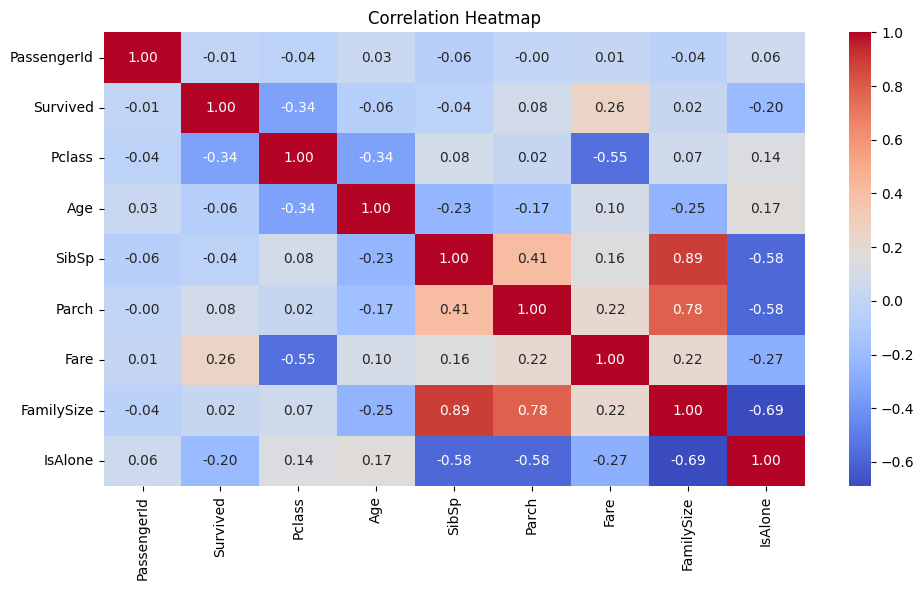

In [18]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm',fmt='.2f')

plt.title('Correlation Heatmap')
plt.tight_layout()

The heatmap indicates that `Pclass` has a moderate negative correlation with `Survived`, suggesting that passengers in higher classes were more likely to survive. `Fare` shows a weak positive relationship with `Survived`, while `IsAlone` has a weak negative correlation with survival outcomes.

### Fare by Survival

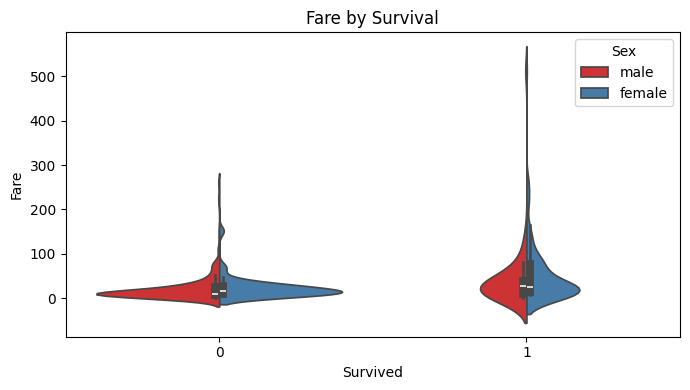

In [19]:
plt.figure(figsize=(7,4))

sns.violinplot(data=df, x='Survived', y='Fare', hue='Sex', split=True, palette='Set1')

plt.title('Fare by Survival')
plt.tight_layout()

Passengers with higher fares were generally more likely to survive. Female passengers also appear to have better survival outcomes across different fare ranges.

### Survival Rate by IsAlone

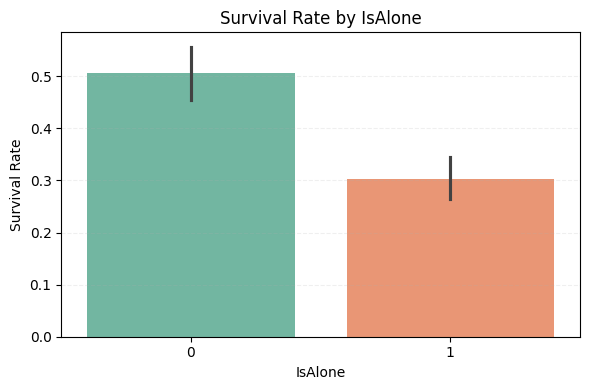

In [20]:
plt.figure(figsize=(6,4))

sns.barplot(data=df, x='IsAlone', y='Survived', hue='IsAlone', palette='Set2', legend=False)

plt.title('Survival Rate by IsAlone')
plt.ylabel('Survival Rate')
plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.tight_layout()

Passengers traveling alone appear to have slightly higher survival rates compared to passengers traveling with family members.

### Family Size and Survival Rate

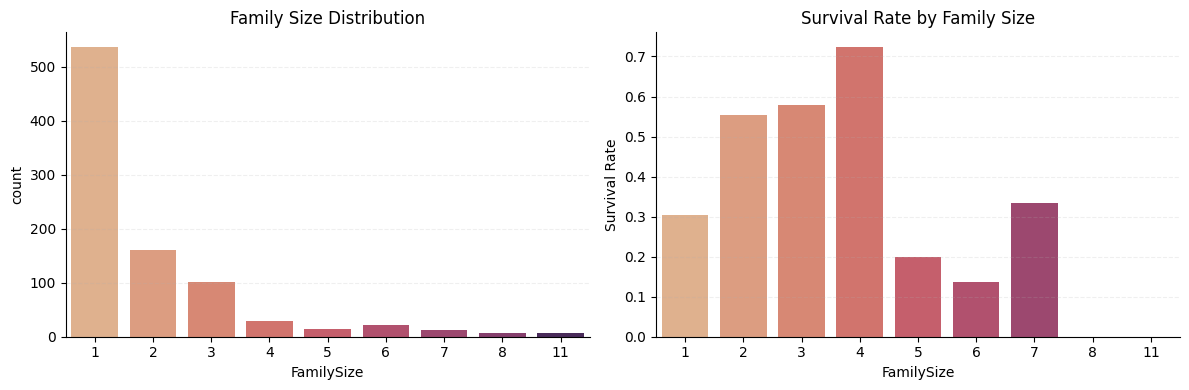

In [21]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.countplot(data=df, x='FamilySize', hue='FamilySize', palette='flare', legend=False, ax=ax[0])
ax[0].grid(axis='y', linestyle='--', alpha=0.2)
ax[0].set_title('Family Size Distribution')

sns.barplot(data=df, x='FamilySize', y='Survived', hue='FamilySize', palette='flare', legend=False, errorbar=None, ax=ax[1])
ax[1].grid(axis='y', linestyle='--', alpha=0.2)
ax[1].set_title('Survival Rate by Family Size')
ax[1].set_ylabel('Survival Rate')

sns.despine()
plt.tight_layout()

Most passengers traveled alone or with small families. Survival rates vary across different family sizes, with medium-sized families showing relatively higher survival rates compared to some larger family groups.